In [1]:
#unhashtag this to install required libraries
#%pip install pandas numpy matplotlib scikit-learn seaborn shap


import sys #System 
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import ops
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam    
from tensorflow.keras.metrics import Precision
from sklearn.preprocessing import StandardScaler
print(tf.__version__)



2.16.2


In [ ]:
#importing datasets
#at minimum include “Age”, “BMI”, and “Blood Glucose Level”

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

target = "HbA1c_level"

#Making y DataFrame for the model
y_train = train[target].astype("float32").values
y_test  = test[target].astype("float32").values


#Dropping columns that we don't need when making the x_train and x_test DataFrame
#train = train.drop(columns=["Unnamed: 0","former", "current", "ever", "never","no info", "not current", target, "male", "female", "other"])
#test = test.drop(columns=["Unnamed: 0","former", "current", "ever", "never", "no info", "not current", target, "male", "female", "other"])

#Base scenario: Removing target and ID column
#train = train.drop(columns=["Unnamed: 0", target])
#test = test.drop(columns=["Unnamed: 0", target])

train = train.drop(columns=["Unnamed: 0", "hypertension", "heart_disease", target, "no info", "other"])
test = test.drop(columns=["Unnamed: 0", "hypertension", "heart_disease", target, "no info", "other"])


#Scaling continuous variables for easier use in model
#Binary columns are already created via preprocessing.
def separate_cols(x):
    bin_col = pd.DataFrame()
    cont_col = pd.DataFrame()
    for col in x.columns:
        if x[col].nunique() == 2:
            bin_col[col] = x[col].values
        else:
            cont_col[col] = x[col].values
    return bin_col, cont_col

train_bin, train_cont = separate_cols(train)
test_bin, test_cont = separate_cols(test)


from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

#Scaling
scaled_tr = sc.fit_transform(train_cont)
scaled_te = sc.transform(test_cont)

#making dataframes for scaled sets
scaled_tr_cont = pd.DataFrame(scaled_tr, columns = train_cont.columns)
scaled_te_cont = pd.DataFrame(scaled_te, columns = test_cont.columns)

#Creating the independent variable datasets 
x_train = pd.concat([train_bin, scaled_tr_cont], axis = 1)
x_test = pd.concat([test_bin, scaled_te_cont], axis = 1)


#Checking dataframe to have all of the columns
print(x_train)


       diabetes  female  male  current  ever  former  never  not current  \
0             0       0     1        0     0       1      0            0   
1             0       0     1        1     0       0      0            0   
2             1       0     1        0     0       0      0            1   
3             0       1     0        0     0       0      0            1   
4             0       1     0        0     0       0      0            0   
...         ...     ...   ...      ...   ...     ...    ...          ...   
76884         0       0     1        0     0       0      1            0   
76885         0       1     0        0     0       0      1            0   
76886         1       0     1        0     0       1      0            0   
76887         0       1     0        0     0       0      0            0   
76888         0       1     0        0     0       0      0            0   

            age       bmi  blood_glucose_level  
0      0.141014  2.521511             

In [ ]:
### Creating Sequential Model ###

model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(x_train.shape[1],)),
        tf.keras.layers.Dense(14, activation="relu"),
        tf.keras.layers.Dense(7, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281 (1.10 KB)

 Trainable params: 281 (1.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Compiling to create backpropigation, loss and metrics

#Call back used to prevent overfitting
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5, restore_best_weights=True)
#Adam used as optimizer for backpropigation
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(delta=0.8), metrics=["mae", "mse"])
ann = model.fit(x_train,y_train,batch_size=128, epochs=100, validation_split=0.2, callbacks=[callback])

###uncomment this when wanting to train another model
#ann2 = model.fit(x_train,y_train,batch_size=64, epochs=100, validation_split=0.2, callbacks=[callback])



Epoch 1/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.7185 - mae: 5.0481 - mse: 26.6353 - val_loss: 3.4428 - val_mae: 4.7036 - val_mse: 23.2615
Epoch 2/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.0276 - mae: 4.1845 - mse: 18.7678 - val_loss: 2.4950 - val_mae: 3.5184 - val_mse: 13.6062
Epoch 3/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7960 - mae: 2.6342 - mse: 8.4583 - val_loss: 1.0983 - val_mae: 1.7425 - val_mse: 4.1002
Epoch 4/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7524 - mae: 1.2945 - mse: 2.4394 - val_loss: 0.5819 - val_mae: 1.0718 - val_mse: 1.6890
Epoch 5/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5519 - mae: 1.0318 - mse: 1.5749 - val_loss: 0.5315 - val_mae: 1.0059 - val_mse: 1.4951
Epoch 6/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5164 - mae: 0.9857 - mse: 1.4338 - val_loss: 0.5043 - val_mae: 0.9715 - val_mse: 1.3836
Epoch 7/100
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4905 - mae: 0.9530 - mse: 1

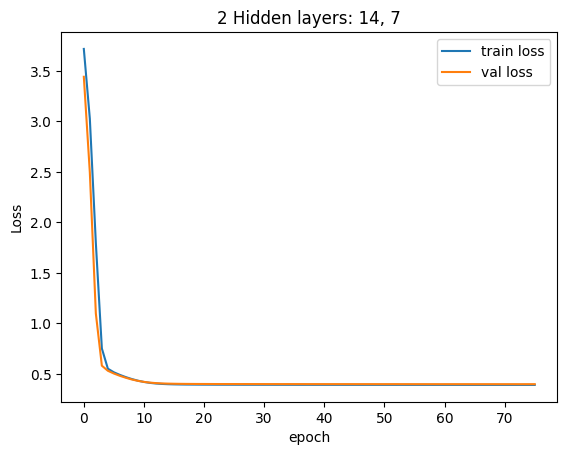

In [9]:
#Importing matplotlib here to start creating plots 
import matplotlib.pyplot as plt


#prints both loss and val_loss to see whether or not the model is learning and/or overfitting
#NOTE: If lines are close together, it means model is generalizing well since curve isn't deviating from the trained model.
plt.plot(ann.history['loss'], label='train loss')
plt.plot(ann.history['val_loss'], label='val loss')
plt.legend(); plt.title("2 Hidden layers: 14, 7"); plt.xlabel('epoch'); plt.ylabel('Loss'); plt.show()





In [28]:
#Testing the data

y_pred = model.predict(x_test,verbose=0).squeeze()

y_pred_df = pd.DataFrame({"y prediction": y_pred})
y_test_df = pd.DataFrame({"y actual": y_test})
predictions = pd.concat([y_pred_df, y_test_df], axis=1)
print(predictions)
#print(y_test)

loss, mae, mse = model.evaluate(x_test, y_test, verbose=1)
print("Test Huber loss:", loss)
print("Test MAE:", mae)
print("Test MSE:", mse)



       y prediction  y actual
0          5.541096       6.6
1          5.449505       4.8
2          5.578034       5.0
3          5.590490       6.1
4          5.590479       6.1
...             ...       ...
19218      5.575664       4.0
19219      6.554921       6.2
19220      5.528804       5.8
19221      5.623508       6.0
19222      5.490360       6.5

[19223 rows x 2 columns]
601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 925us/step - loss: 0.3954 - mae: 0.8383 - mse: 1.0010
Test Huber loss: 0.39535990357398987
Test MAE: 0.838339626789093
Test MSE: 1.000996470451355


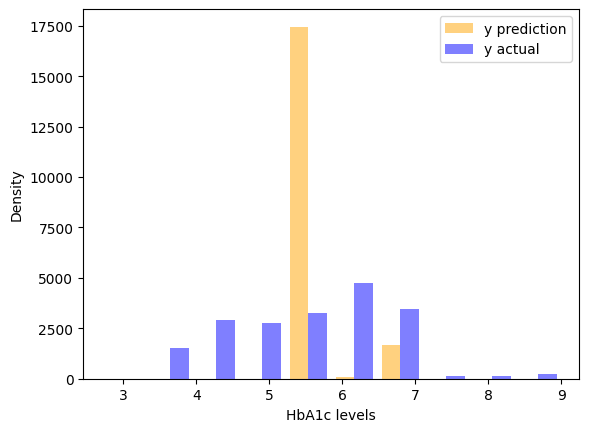

In [29]:
# Histogram with density
plt.hist(predictions, alpha=0.5, color=["orange", "blue"])
plt.legend(predictions)

# Plot a line through the histogram (midpoints vs density)
plt.xlabel("HbA1c levels")
plt.ylabel("Density")
plt.show()


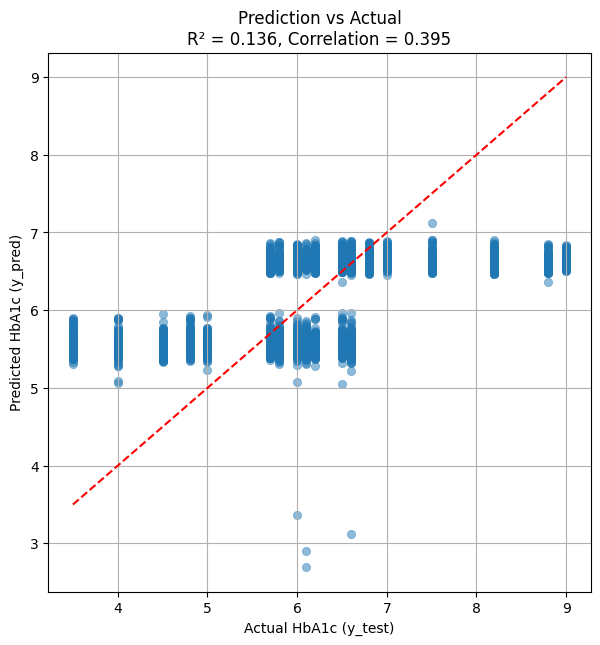

In [7]:
import seaborn as sns
from sklearn.metrics import r2_score
# Compute correlation (R² and Pearson's r) to test the correlation between the Actual hba1c and Predicted hba1c
#These variables are to be used in the title
r2 = r2_score(y_test, y_pred)
corr = np.corrcoef(y_test, y_pred)[0,1]

# Plot correlation scatter
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line

#Adding the lables to make the graph understandable.
plt.xlabel("Actual HbA1c (y_test)")
plt.ylabel("Predicted HbA1c (y_pred)")
plt.title(f"Prediction vs Actual\nR² = {r2:.3f}, Correlation = {corr:.3f}")
plt.grid(True)
plt.show()

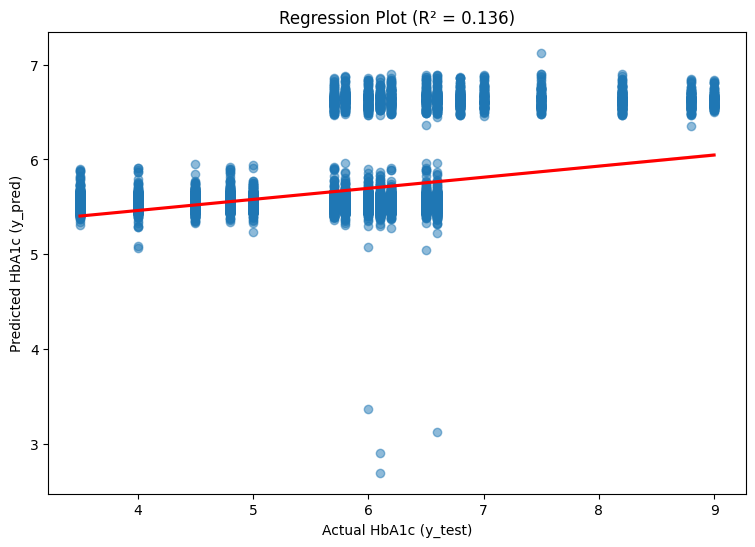

In [8]:
#Regression plot is used as another means to 
y_pred = y_pred.flatten()

# Compute R²
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(9,6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={"color":"red"})

plt.xlabel("Actual HbA1c (y_test)")
plt.ylabel("Predicted HbA1c (y_pred)")
plt.title(f"Regression Plot (R² = {r2:.3f})")

plt.show()

In [9]:
#Using shap to test feature importance in our dataset.

import shap


explainer = shap.Explainer(model, x_train)
shap_values = explainer(x_test)
# Summary plot (feature importance as beeswarm)
#shap.summary_plot(shap_values, x_test, feature_names=x_test.columns)

# Bar plot of average absolute importance
#shap.summary_plot(shap_values, x_test, feature_names=x_test.columns, plot_type="bar")

PermutationExplainer explainer:   5%|▌         | 1035/19223 [02:17<40:23,  7.50it/s] 


KeyboardInterrupt: 

In [ ]:
#print(x_test)
#print(y_test_df)

In [ ]:
#Writing predictions into csv

#predictions.to_csv("prediction_continuous.csv", index=False)

#pd.DataFrame(ann.history).to_csv("training_hba1c.csv", index=False)

In [ ]:
#from sklearn.linear_model import LinearRegression
#reg = LinearRegression().fit(x_train, y_train)
#print("Baseline R^2 (train):", reg.score(x_train, y_train))
#print("Baseline R^2 (test):", reg.score(x_test, y_test))
